In [1]:
import torch
from torch import nn
print(torch.__version__)

2.10.0+cpu


In [2]:
from sklearn.datasets import make_circles

n_samples =1000

X,y = make_circles(n_samples,noise=0.03,random_state=42)

In [3]:
print(f"first 5 X features:\n{X[:5]}")
print(f"first 5 X features:\n{y[:5]}")

first 5 X features:
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
first 5 X features:
[1 1 1 1 0]


In [4]:
import pandas as pd 
circles = pd.DataFrame({"X1":X[:,0],"X2":X[:,1], "label":y})
circles.head(10)


,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


In [5]:
circles.label.value_counts()

label
1    500
0    500
Name: count, dtype: int64

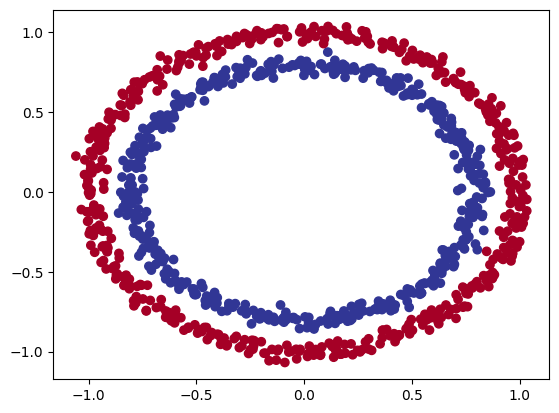

In [6]:
import matplotlib.pyplot as plt
plt.scatter(x=X[:,0],y=X[:,1],c=y,cmap = plt.cm.RdYlBu)

In [7]:
# Check the shapes of our features and labels
X.shape, y.shape

((1000, 2), (1000,))

In [8]:
# View the first example of features and labels
X_sample = X[0]
y_sample = y[0]
print(f"Values for one sample of X: {X_sample} and the same for y: {y_sample}")
print(f"Shapes for one sample of X: {X_sample.shape} and the same for y: {y_sample.shape}")

Values for one sample of X: [0.75424625 0.23148074] and the same for y: 1
Shapes for one sample of X: (2,) and the same for y: ()


tensor([[-8.4134,  6.9352],
        [-5.7665, -6.4312],
        [-6.0421, -6.7661],
        [ 3.9508,  0.6984],
        [ 4.2505, -0.2815]]) tensor([3, 2, 2, 1, 1])


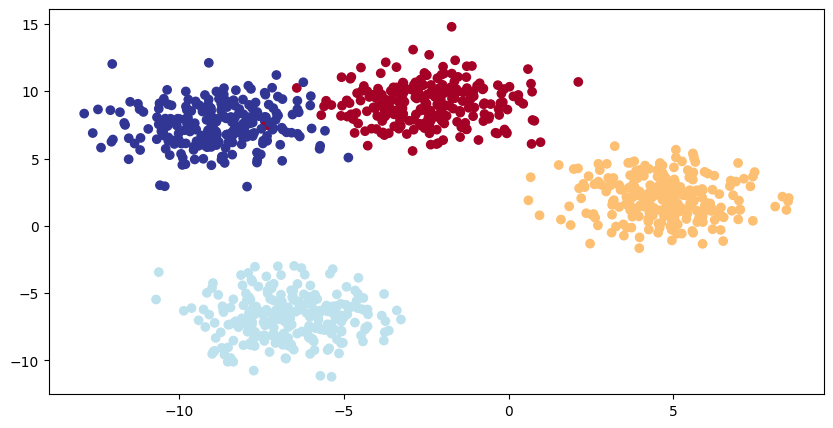

In [45]:
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
#Set the hyperparameters from data creation
NUM_CLASSES =4
NUM_FEATURES = 2
RANDOM_SEED =42

#Create multi class data

X_blob,y_blob = make_blobs(n_samples=1000,n_features=NUM_FEATURES ,# X features
                          centers = NUM_CLASSES, #Y labels
                          cluster_std=1.5, # give the clusters a little shake up
                          random_state=RANDOM_SEED)

#Turn data into tensors
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)
print(X_blob[:5], y_blob[:5])

#split train and split dataset
X_blob_train, X_blob_test, y_blob_train,y_blob_test = train_test_split(X_blob,y_blob,test_size=0.2,random_state= RANDOM_SEED)

#Plot data
plt.figure(figsize=(10,5))
plt.scatter(X_blob[:,0],X_blob[:,1], c=y_blob,cmap=plt.cm.RdYlBu)

In [46]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [56]:
from torch import nn

#Build model
class BlobModel(nn.Module):
    def __init__(self, input_features,output_features,hidden_units=8):
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
           nn.Linear(in_features=input_features,out_features=hidden_units) ,
           #nn.ReLU(),
           nn.Linear(in_features=hidden_units,out_features=hidden_units),
           #nn.ReLU(),
           nn.Linear(in_features=hidden_units,out_features=output_features)
        )
        
    def forward(self,x):
        return self.linear_layer_stack(x)
    
model4 = BlobModel(input_features = NUM_FEATURES, output_features=NUM_CLASSES,hidden_units=8).to(device)
model4  

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [57]:
#Create loss function
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model4.parameters())


In [58]:
#Testing for single pass
model4(X_blob_train.to(device))[:5]

tensor([[-1.2711, -0.6494, -1.4740, -0.7044],
        [ 0.2210, -1.5439,  0.0420,  1.1531],
        [ 2.8698,  0.9143,  3.3169,  1.4027],
        [ 1.9576,  0.3125,  2.2244,  1.1324],
        [ 0.5458, -1.2381,  0.4441,  1.1804]], grad_fn=<SliceBackward0>)

In [59]:
print(X_blob_test[:5])
print(X_blob_test.shape)
print(X_blob_test.dtype)
print(NUM_FEATURES)
print(NUM_CLASSES)

tensor([[ 4.6675,  4.4878],
        [-7.9969,  6.8803],
        [-6.2801, -7.8571],
        [ 3.6833,  1.1767],
        [-0.1404, 10.1654]])
torch.Size([200, 2])
torch.float32
2
4


In [60]:
print("X_blob_test shape:", X_blob_test.shape)
print("X_blob_test dtype:", X_blob_test.dtype)

print("y_blob_test shape:", y_blob_test.shape)
print("y_blob_test dtype:", y_blob_test.dtype)

X_blob_test shape: torch.Size([200, 2])
X_blob_test dtype: torch.float32
y_blob_test shape: torch.Size([200])
y_blob_test dtype: torch.int64


In [38]:
# # Make prediction logits with model
# y_logits = model4(X_blob_test.to(device))

# # Perform softmax calculation on logits across dimension 1 to get prediction probabilities
# y_pred_probs = torch.softmax(y_logits, dim=1) 
# print(y_logits[:5])
# print(y_pred_probs[:5])

In [39]:
# # Sum the first sample output of the softmax activation function 
# torch.sum(y_pred_probs[0])
# # Which class does the model think is *most* likely at the index 0 sample?
# print(y_pred_probs[0])
# print(torch.argmax(y_pred_probs[0]))

In [61]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

#Training and testin loop
torch.manual_seed(42)

#set no of epochs
epochs = 100

#put dataset in target device 
X_blob_train,y_blob_train = X_blob_train.to(device),y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

for epoch in range(epochs):
    #Training
    model4.train()
    
    #forward pass
    y_logits  = model4(X_blob_train)
    y_pred = torch.softmax(y_logits,dim=1).argmax(dim=1) ## go from logits -> prediction probabilities -> prediction labels
   # print(y_logits)
    
    #loss calculation and accuacy
    loss = loss_fn(y_logits,y_blob_train)
    acc = accuracy_fn(y_true=y_blob_train,y_pred=y_pred)
    
    #optimizer 
    optimizer.zero_grad()
    
    #loss backward
    loss.backward()
    
    #optmizer step
    optimizer.step()
    
    #Testing
    model4.eval()
    with torch.inference_mode():
        test_logits = model4(X_blob_test)
        test_pred = torch.softmax(test_logits,dim=1).argmax(dim=1)
        test_loss = loss_fn(test_logits, y_blob_test)
        test_acc = accuracy_fn(y_true=y_blob_test,
                             y_pred=test_pred)
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 1.04324, Acc: 65.50% | Test Loss: 1.02215, Test Acc: 68.00%
Epoch: 10 | Loss: 0.97814, Acc: 68.38% | Test Loss: 0.95948, Test Acc: 71.00%
Epoch: 20 | Loss: 0.92154, Acc: 70.12% | Test Loss: 0.90507, Test Acc: 73.00%
Epoch: 30 | Loss: 0.87187, Acc: 71.38% | Test Loss: 0.85737, Test Acc: 73.50%
Epoch: 40 | Loss: 0.82790, Acc: 71.75% | Test Loss: 0.81516, Test Acc: 74.00%
Epoch: 50 | Loss: 0.78867, Acc: 72.50% | Test Loss: 0.77752, Test Acc: 74.00%
Epoch: 60 | Loss: 0.75341, Acc: 73.12% | Test Loss: 0.74369, Test Acc: 74.00%
Epoch: 70 | Loss: 0.72152, Acc: 73.25% | Test Loss: 0.71307, Test Acc: 74.00%
Epoch: 80 | Loss: 0.69250, Acc: 73.50% | Test Loss: 0.68520, Test Acc: 74.00%
Epoch: 90 | Loss: 0.66597, Acc: 74.88% | Test Loss: 0.65968, Test Acc: 74.50%


In [62]:
# Make predictions
model4.eval()
with torch.inference_mode():
    y_logits = model4(X_blob_test)

# View the first 10 predictions
y_logits[:10]

tensor([[-0.7443, -0.2073, -2.2383, -1.1258],
        [ 2.1210, -1.6723,  1.3247,  2.4747],
        [ 1.6024,  0.0665,  3.5722,  1.6938],
        [-0.5532,  0.0526, -1.2989, -0.9171],
        [ 0.3865, -1.2731, -1.7892,  0.3380],
        [ 2.5251, -1.9456,  1.6961,  2.9884],
        [ 1.1802,  0.3226,  3.1260,  1.1597],
        [ 0.8327, -1.3462, -0.9301,  0.8851],
        [ 2.2643, -0.2495,  4.4394,  2.5236],
        [ 0.6616, -1.2980, -1.2199,  0.6735]])

In [63]:
# Turn predicted logits in prediction probabilities
y_pred_probs = torch.softmax(y_logits, dim=1)

# Turn prediction probabilities into prediction labels
y_preds = y_pred_probs.argmax(dim=1)

# Compare first 10 model preds and test labels
print(f"Predictions: {y_preds[:10]}\nLabels: {y_blob_test[:10]}")
print(f"Test accuracy: {accuracy_fn(y_true=y_blob_test, y_pred=y_preds)}%")

Predictions: tensor([1, 3, 2, 1, 0, 3, 2, 3, 2, 3])
Labels: tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])
Test accuracy: 78.5%


In [64]:
import requests
from pathlib import Path 

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

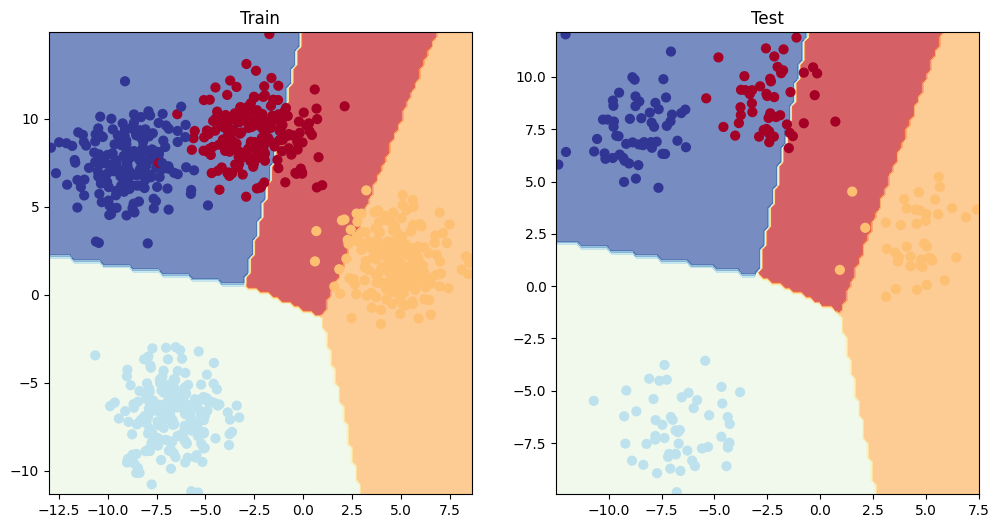

In [65]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model4, X_blob_train, y_blob_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model4, X_blob_test, y_blob_test)